d:\DS102\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
d:\DS102\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(


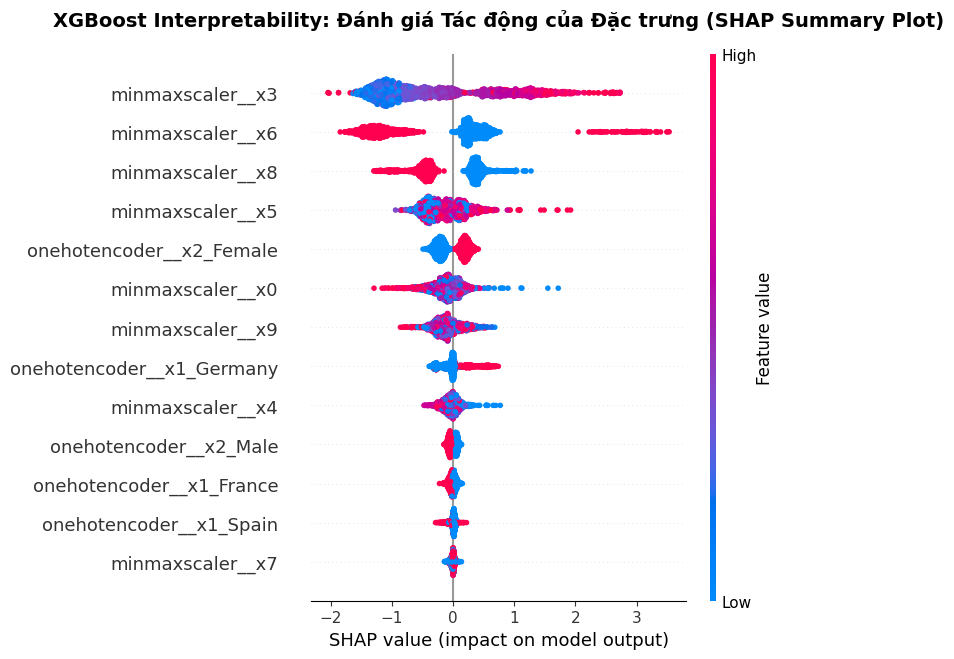

In [4]:
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ==========================================
# BƯỚC 1: LOAD DỮ LIỆU VÀ CẮT TẬP TEST
# ==========================================
# Đọc file dữ liệu đã qua bước Feature Engineering
df = pd.read_csv('../data/churn_prepared_data.csv') 

X = df.drop(columns=['Exited'])
y = df['Exited']

# Lưu ý: Cắt train_test_split y hệt như lúc train để đảm bảo tập X_test đồng nhất
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# BƯỚC 2: TẢI MÔ HÌNH VÀ TRÍCH XUẤT PIPELINE
# ==========================================
# Load file .sav của XGBoost đã được GridSearch tối ưu
xgb_saved = joblib.load('../models/xgb_weighted.sav') 
best_xgb_pipe = xgb_saved.best_estimator_

# Trích xuất 2 phần cốt lõi từ Pipeline: Bộ mã hóa và Mô hình học
preprocessor = best_xgb_pipe.named_steps['preprocessor']
xgb_model = best_xgb_pipe.named_steps['xgb_weighted']

# ==========================================
# BƯỚC 3: TIỀN XỬ LÝ X_TEST ĐỂ SHAP ĐỌC ĐƯỢC
# ==========================================
# Chuyển đổi X_test qua OneHotEncoder và StandardScaler
X_test_transformed = preprocessor.transform(X_test)

# Lấy lại tên cột sau khi biến đổi (VD: Geography_Germany) để biểu đồ hiển thị đẹp
feature_names = preprocessor.get_feature_names_out()
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)

# ==========================================
# BƯỚC 4: CHẠY SHAP VÀ VẼ BIỂU ĐỒ SUMMARY
# ==========================================
# Khởi tạo JS để vẽ hình đẹp hơn trong Notebook
shap.initjs()

# Dùng TreeExplainer (siêu nhanh, thiết kế riêng cho XGBoost/Random Forest)
explainer = shap.TreeExplainer(xgb_model)

# Tính toán giá trị SHAP cho tập Test
shap_values = explainer.shap_values(X_test_shap)

# Cấu hình khung và vẽ biểu đồ Summary Plot
plt.figure(figsize=(10, 8))
plt.title("XGBoost Interpretability: Đánh giá Tác động của Đặc trưng (SHAP Summary Plot)", 
          fontsize=14, fontweight='bold', pad=20)

# summary_plot sẽ tự động hiển thị ra màn hình
shap.summary_plot(shap_values, X_test_shap)

⏳ Đang chạy mRMR để lọc Top 10 biến tối ưu nhất...


100%|██████████| 10/10 [00:05<00:00,  1.88it/s]


✅ Danh sách Top 10 biến được giữ lại:
['minmaxscaler__x3', 'onehotencoder__x1_Spain', 'onehotencoder__x2_Female', 'minmaxscaler__x8', 'minmaxscaler__x5', 'onehotencoder__x1_Germany', 'minmaxscaler__x0', 'onehotencoder__x2_Male', 'onehotencoder__x1_France', 'minmaxscaler__x9']


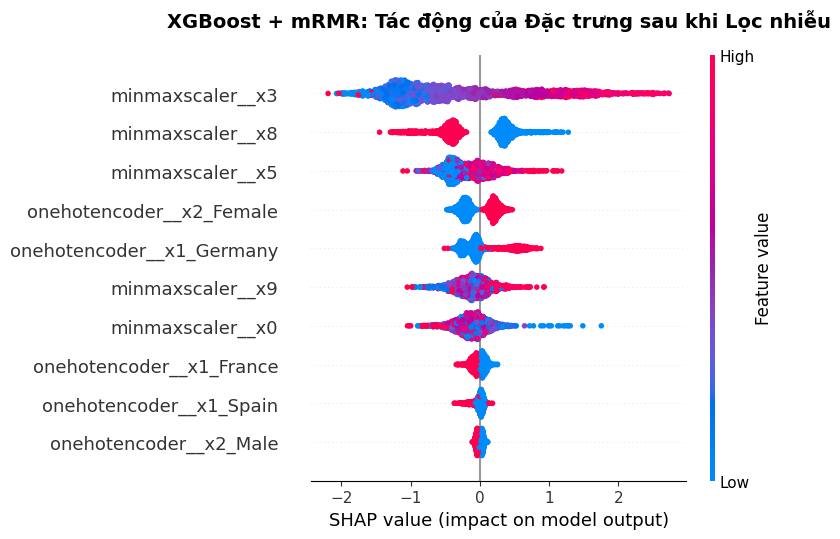

In [9]:
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mrmr import mrmr_classif
from xgboost import XGBClassifier

# ==========================================
# BƯỚC 1: LOAD DỮ LIỆU VÀ CẮT TẬP TRAIN/TEST
# ==========================================
df = pd.read_csv('../data/churn_prepared_data.csv') 

X = df.drop(columns=['Exited'])
y = df['Exited']

# Cắt y hệt như cũ
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# ==========================================
# BƯỚC 2: MƯỢN "NỘI CÔNG" TỪ MÔ HÌNH CŨ
# ==========================================
xgb_saved = joblib.load('../models/xgb_weighted.sav') 
best_xgb_pipe = xgb_saved.best_estimator_

# Rút bộ mã hóa và mô hình cũ ra
preprocessor = best_xgb_pipe.named_steps['preprocessor']
old_xgb_model = best_xgb_pipe.named_steps['xgb_weighted']

# ==========================================
# BƯỚC 3: TIỀN XỬ LÝ ĐỂ CHẠY MRMR
# ==========================================
# Biến đổi cả Train và Test qua OneHot/Scaler trước khi lọc
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# Chuyển thành DataFrame để mRMR dễ đọc
X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Sau khi tạo X_train_df và X_test_df
X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names).reset_index(drop=True)
X_test_df  = pd.DataFrame(X_test_transformed,  columns=feature_names).reset_index(drop=True)

# Reset index cho y_train (rất quan trọng)
y_train_reset = y_train.reset_index(drop=True)

# ==========================================
# BƯỚC 4: CHẠY BỘ LỌC mRMR (Lọc rác, giữ tinh hoa)
# ==========================================
print("⏳ Đang chạy mRMR để lọc Top 10 biến tối ưu nhất...")
# K=10 là số biến muốn giữ lại, bạn có thể chỉnh thành 8 hoặc 12 tùy ý
selected_features = mrmr_classif(X=X_train_df, y=y_train_reset, K=10)

print("✅ Danh sách Top 10 biến được giữ lại:")
print(selected_features)

# Lọc lại dữ liệu chỉ lấy các biến đã chọn
X_train_mrmr = X_train_df[selected_features]
X_test_mrmr = X_test_df[selected_features]

# ==========================================
# BƯỚC 5: TRAIN LẠI XGBOOST VÀ CHẠY SHAP
# ==========================================
# Thủ thuật: Copy y nguyên các tham số (scale_pos_weight, max_depth...) từ mô hình cũ
xgb_mrmr = XGBClassifier(**old_xgb_model.get_params())

# Train lại mô hình trên tập dữ liệu đã lọc
xgb_mrmr.fit(X_train_mrmr, y_train)

# Khởi tạo SHAP và vẽ biểu đồ
shap.initjs()
explainer = shap.TreeExplainer(xgb_mrmr)
shap_values = explainer.shap_values(X_test_mrmr)

plt.figure(figsize=(10, 8))
plt.title("XGBoost + mRMR: Tác động của Đặc trưng sau khi Lọc nhiễu", 
          fontsize=14, fontweight='bold', pad=20)
shap.summary_plot(shap_values, X_test_mrmr)